<a href="https://colab.research.google.com/github/morena2712/DataMiningProject/blob/main/Progetto_DM_Definitivo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificazione del genere e Clustering di film

## Introduzione

Il seguente progetto prende in considerazione un dataset (fonte: Kaggle) che raccoglie diverse variabili in riferimento a 50.000 film non reali, ma pensati esclusivamente per lo scopo del dataset.  
Le variabili che vengono considerate per ogni film sono, in particolare:


*  **Title**, ovvero un nome di fantasia identificativo del film;
+ **Year**, ovvero l'ipotetico anno di uscita;
+ **Director**, ovvero il nome di fantasia del regista;
+ **Duration**, ovvero la lunghezza del film in minuti;
+ **Rating**, ovvero la valutazione del film in stile IMDb (punteggio da 1 a 10);
+ **Votes**, ovvero il numero di voti;
+ **Description**, ovvero un breve riassunto della trama;
+ **Language**, ovvero la lingua originale del film;
+ **Country**, ovvero il paese di produzione del film;
+ **Budget_USD**, ovvero la stima del budget di produzione in dollari statunitensi;
+ **BoxOffice_USD**, ovvero la stima delle entrate al botteghino del film in dollari statunitensi;
+ **Genre**, ovvero il genere del film;
+ **Production_Company**, ovvero il nome dello studio di distribuzione;
+ **Content_Rating**, ovvero la valutazione della fascia di pubblico adatta per il film (ad esempio PG-13, PG-18,...);
+ **Lead_Actor**, ovvero i nomi di fantasia degli attori principali;
+ **Num_Awards**, ovvero il numero di premi vinti;
+ **Critic_Reviews**, ovvero il numero di recensioni critiche.  

Per quanto riguarda la variabile **Genre**, questa si divide sette modalità predefinite, ovvero **Action**, **Comedy**, **Drama**, **Romance**, **Thriller**, **Horror** e **Fantasy**. Questa sarà la variabile che il modello di classificazione dovrà individuare.  

L'obiettivo del progetto è quello di utilizzare diversi modelli di classificatori per confrontarne l'accuratezza e l'errore. In particolare, verranno usati il modello **Decision Tree**, il **Multinominal Naive Bayes** e il **Support Vector Machine**, prendendo in considerazione le variabili di **Title**, **Year**, **Director**, **Description**, **Country**, **Production_Company**, **Content_Rating** e **Lead_Actor**.  
Successivamente si procederà a valutare la divisione in cluster attraverso il metodo **K-means** con l'obiettivo di rappresentare l'ipotesi che i film si distribuiscano spontaneamente per genere, definendo quindi classi omogenee.

## Decision Tree

Il modello **Decision Tree** è un algoritmo di Machine Learning supervisionato usato sia per i compiti di classificazione, che per quelli di regressione. Le decisioni e le conseguenze di queste vengono modellizzate in una struttura ad albero, costruito dividendo i dati sulla base dei valori delle caratteristiche che meglio predicono la variabile target. L'obiettivo è creare un albero che sia in grado di classificare nuovi dati seguendo la struttura creata.  

In questo modello prenderemo in considerazione le variabili **Title**, **Year**, **Director**, **Description**, **Country**, **Production_Company**, **Content_Rating**, **Lead_Actor** e **Critic_Reviews**.  

Innanzitutto, carichiamo il dataset su Python.

In [5]:
import pandas as pd

data = pd.read_csv('/content/movie_genre_classification_final.csv')
display(data.head())

,Title,Year,Director,Duration,Rating,Votes,Description,Language,Country,Budget_USD,BoxOffice_USD,Genre,Production_Company,Content_Rating,Lead_Actor,Num_Awards,Critic_Reviews
0,Winds of Fate 4,1980,R. Lee,167,4.1,182425,A touching love story with heartwarming moments.,Spanish,China,39979615,179936008,Romance,DreamWorks,R,Kangana Ranaut,8,229
1,Firestorm 11,2014,S. Chen,166,4.1,449351,A fast-paced thriller with intense action scenes.,Korean,China,116404774,802121619,Action,Netflix,R,Kangana Ranaut,20,466
2,Silent Echo 2,2016,A. Khan,170,4.1,363328,A fast-paced thriller with intense action scenes.,Korean,Japan,166261330,225526871,Action,Pixar,PG,Amitabh Bachchan,16,539
3,City Lights 4,1982,L. Zhang,170,9.9,62371,An emotional journey exploring complex charact...,Japanese,Japan,28861315,69813738,Drama,Netflix,NC-17,Natalie Portman,15,606
4,Broken Truth 1,1990,L. Zhang,91,5.3,4600,An imaginative world filled with magic and won...,Korean,USA,43890403,375136716,Fantasy,Studio Ghibli,PG,Chris Evans,6,330


Successivamente, si utilizzano i pacchetti **scikit-learn**, che contiene algoritmi di apprendimento per i classificatori, e **numpy**, utile per creare e supportare matrici e vettori multidimensionali di grandi dimensioni. In particolare, vengono adottati i moduli **tree**, **train_test_split** e **LabelEncoder** da **scikit-learn** per, rispettivamente, creare un albero decisionale, dividere il dataset in dati di addestamento e dati di test, e codificare le variabili categoriali in numeri.
Creiamo quindi un oggetto **Y** a cui verranno assegnate tutte le osservazioni della colonna **Genre** e che verrà convertito attraverso **.to_numpy()** in un **ndarray**. Infine, creiamo un oggetto **X** a cui verranno assegnate le variabili elencate precedentemente.  
Poiché la X è composta sia di variabili numeriche che di variabili categoriali, c'è bisogno di codificare quest'ultime. Per farlo, come detto in precedenza, si utilizza il modulo di scikit-learn **LabelEncoder**. In particolare, si avvia un **ciclo for** per cui le colonne che presentano stringhe all'interno vengono convertite in numeri interi.  

Dopo aver effettuato questo pre-processamento dei dati, questi vengono scomposti in **Train set**, che comprenderà l'80\% dei dati, e **Test set**, che comprenderà il 20\% dei dati. Si manderanno poi i comandi per visualizzare a schermo le **X di addestramento**, le **Y di addestramento**, le **X di test** e le **Y di test**.

In [6]:
from sklearn import tree
from sklearn.model_selection import train_test_split

Y=data['Genre'].to_numpy()

from sklearn.preprocessing import LabelEncoder

X_df = data.drop(['Duration', 'Rating', 'Votes', 'Language', 'Budget_USD', 'BoxOffice_USD', 'Genre', 'Num_Awards'], axis=1)

for col in X_df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    X_df [col] = le.fit_transform(X_df[col])

X_train_df, X_test_df, y_train, y_test = train_test_split(X_df, Y, test_size=0.2, random_state=42)
X_train_df

,Title,Year,Director,Description,Country,Production_Company,Content_Rating,Lead_Actor,Critic_Reviews
39087,203,2001,8,1,6,9,3,8,11
30893,44,2016,6,1,3,1,4,4,763
45278,223,2012,6,6,2,4,3,4,12
16398,246,2017,8,1,3,8,4,0,103
13653,6,1999,2,4,0,6,1,8,268
...,...,...,...,...,...,...,...,...,...
11284,47,2006,9,0,4,8,1,5,760
44732,239,2008,2,4,6,3,2,1,548
38158,60,2005,4,1,5,0,4,0,966
860,102,2022,1,5,3,2,4,2,422


In [7]:
X_test_df

,Title,Year,Director,Description,Country,Production_Company,Content_Rating,Lead_Actor,Critic_Reviews
33553,154,2001,7,2,6,3,1,6,500
9427,244,1987,1,3,1,7,1,8,683
199,33,2000,7,0,4,6,3,6,390
12447,197,1998,2,3,6,0,3,7,516
39489,193,1996,6,4,5,3,4,8,922
...,...,...,...,...,...,...,...,...,...
28567,42,2008,6,2,3,5,3,9,355
25079,77,2000,2,5,1,3,4,2,769
18707,19,1980,9,6,5,7,3,0,445
15200,112,1989,0,4,4,9,3,9,93


In [8]:
y_train

array(['Comedy', 'Comedy', 'Fantasy', ..., 'Comedy', 'Drama', 'Fantasy'],
      dtype=object)

In [9]:
y_test

array(['Horror', 'Thriller', 'Action', ..., 'Fantasy', 'Romance',
       'Romance'], dtype=object)

Si sviluppa ora la struttura dell'albero decisionale, creando un oggetto **clf** che rappresenta il classificatore. Si specificano i parametri: **criterion='gini'** per specificare la regola con cui il modello dovrà misurare la qualità delle suddividioni (l'**indice di Gini** in questo caso), e **max_depth=3** per indicare la profondità dell'albero e limitarla a tre livelli in modo che il modello non diventi troppo complesso o cada nell'**overfitting**.  
Successivamente, si addestra il modello attraverso l'uso di **.fit(...)**. Il dataframe **X_train** viene convertino in un ndarray tramite **.to_numpy()**, necessario per l'uso del modello sklearn.  
Dopo aver addestrato il modello, viene applicato ai dati di test attraverso **clf.predict(...)**, che restituisce un array con le predizione dei generi dei film nel set di dati di test.  
Infine, si manda il comando per visualizzare a schermo l'array con le predizioni.

In [10]:
clf = tree.DecisionTreeClassifier(criterion='gini', max_depth=3)
clf = clf.fit(X_train_df.to_numpy(), y_train)

predY= clf.predict(X_test_df.to_numpy())
predY

array(['Horror', 'Thriller', 'Action', ..., 'Fantasy', 'Romance',
       'Romance'], dtype=object)

Trasformiamo ora l'array in un dataframe in cui si prendono in considerazione la colonna **Title** del set di dati di test, eliminando l'indicizzazione in modo da allinearli al nuovo array di dati con le predizioni, e i dati predetti, trasformandoli in una **Series** con **Pandas** e chiamandoli **Predicted Genre**. Con **pd.concat([...], axis=1)** predisponiamo uno affianco all'altro, per colonna, i titoli e i rispettivi generi predetti. Infine, mandiamo il comando per visualizzare a schermo il dataframe.

In [11]:
predictions= pd.concat([X_test_df['Title'].reset_index(drop=True), pd.Series(predY, name='Predicted Genre')], axis=1)
predictions

,Title,Predicted Genre
0,154,Horror
1,244,Thriller
2,33,Action
3,197,Thriller
4,193,Romance
...,...,...
9995,42,Horror
9996,77,Drama
9997,19,Fantasy
9998,112,Romance


Visualizziamo l'albero decisionale. Per creare il grafico verrà usato **matplotlib.pyplot**.

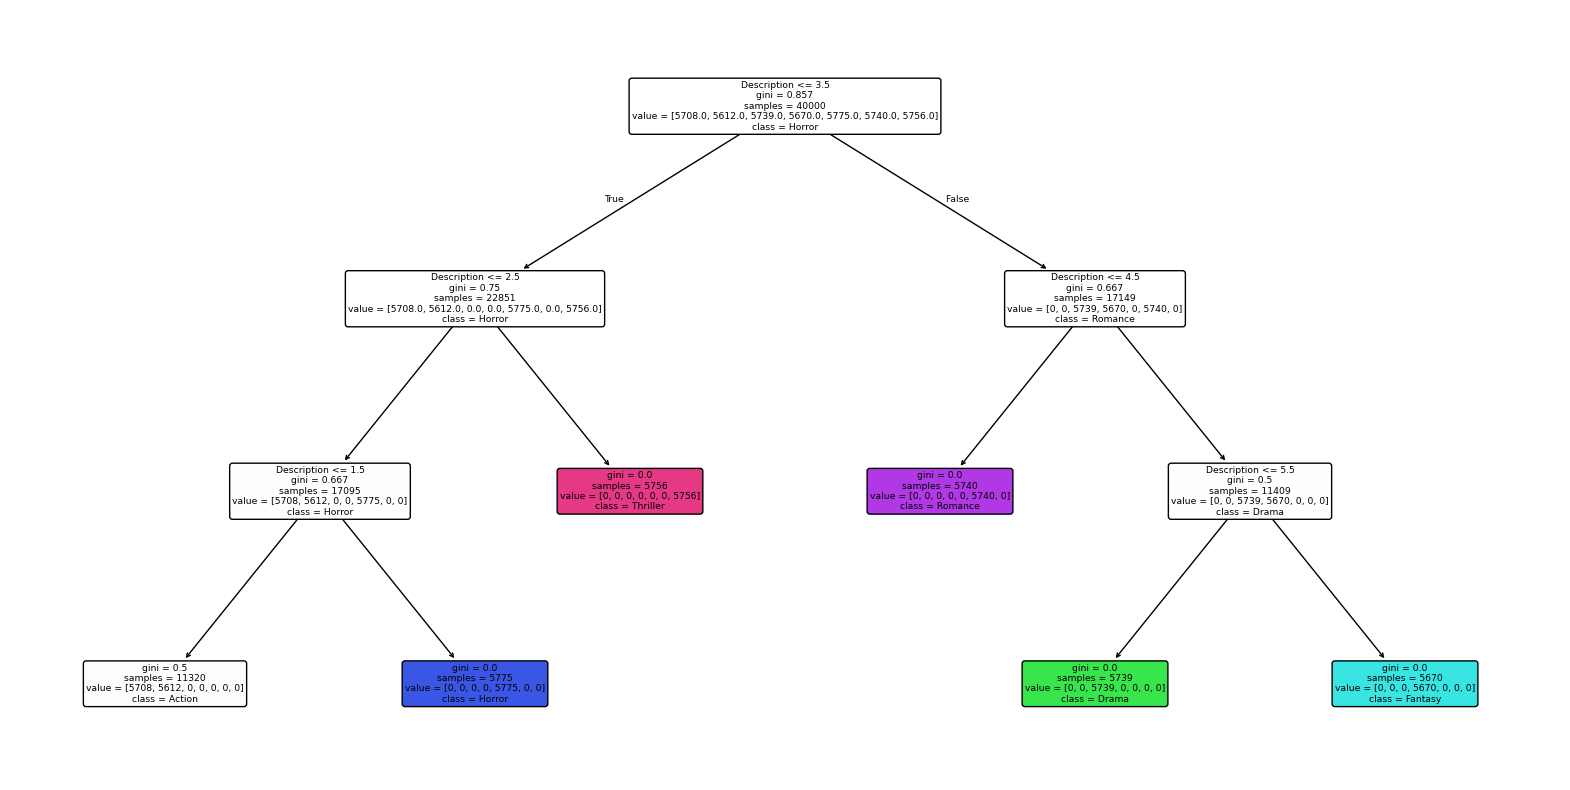

In [12]:
from sklearn import tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))
tree.plot_tree(clf,
               feature_names=X_df.columns,
               class_names=clf.classes_,
               filled=True,
               rounded=True)
plt.show()

Conclusa la creazione del modello e visualizzato l'albero, calcoliamo ora l'**accuratezza** del modello.

In [13]:
from sklearn.metrics import accuracy_score

print('Accuracy on test data is %.2f' % (accuracy_score(y_test, predY)))

Accuracy on test data is 0.86


L'accuratezza del modello risulta dell'86\%, quindi le predizioni sono molto accurate.  
Per verificare che le classi non siano sbilanciate e che il modello sia in grado di generalizzare efficacemente i risultati, si crea una **Confusion Matrix** attraverso i moduli di scikit-learn e matplotlib.pyplot.  
La Matrice di Confusione confronta le etichette reali con quelle predette, creando una matrice che mostra quanti film sono stati classificati correttamento o meno per ciascun genere.

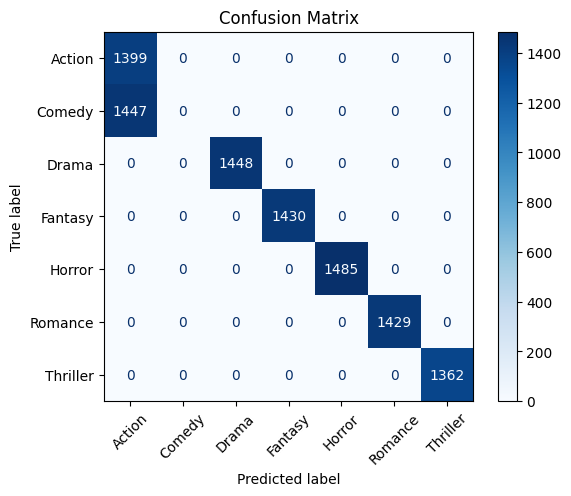

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, predY, labels=clf.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

Il modello sembra non riuscire a classificare correttamente i film comici.  
Per verificare l'**overfitting** del modello, testiamo diversi alberi decisionali con i dati di addestramento e di test per vedere come potrebbe cambiare l'accuratezza del modello.

Text(0, 0.5, 'Accuracy')

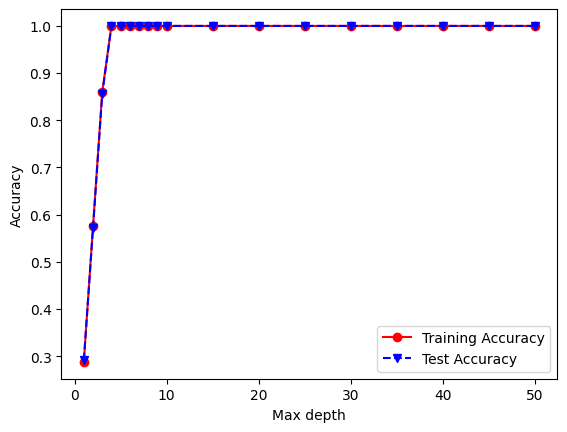

In [15]:
from sklearn.metrics import mean_absolute_error
import numpy as np

maxdepths = [1,2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50]

trainAcc = np.zeros(len(maxdepths))
testAcc = np.zeros(len(maxdepths))

index = 0
for depth in maxdepths:
    clf = tree.DecisionTreeClassifier(max_depth=depth)
    clf = clf.fit(X_train_df, y_train)
    Y_predTrain = clf.predict(X_train_df)
    Y_predTest = clf.predict(X_test_df)
    trainAcc[index] = accuracy_score(y_train, Y_predTrain)
    testAcc[index] = accuracy_score(y_test, Y_predTest)
    index += 1

plt.plot(maxdepths,trainAcc,'ro-',maxdepths,testAcc,'bv--')
plt.legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Max depth')
plt.ylabel('Accuracy')

Il modello potrebbe essere soggetto ad **overfitting**.

## Multinominal Naive Bayes

Il modello **Multinomial Naive Bayes** è una variante dell’algoritmo **Naive Bayes** ed è utilizzato per la classificazione di testi. Presuppone che tutte le feature siano indipendenti tra loro, anche se questa è una condizione che raramente si presenta. Il modello considera la frequenza delle **features**, ovvero quante volte compare una parola in un documento.  

Nel modello che si svilupperà saranno prese in considerazione solo le variabili **Title** e **Description** del dataset di riferimento. L'obiettivo è riuscire a classificare il genere dei film a partire da queste informazioni.  
Successivamente, si calcolerà l'accuratezza del modello, confrontandola con il precedente.  

Poiché il dataset è lo stesso, possiamo procedere a creare gli oggetti **X_nb**, a cui sono assegnate le colonne delle variabili del titolo e della descrizione, e **Y_nb**, a cui è assegnata la colonna del genere. Per proseguire con le analisi, si crea un oggetto **X_nb_combined** in cui le modalità del titolo e della descrizione vengono unite in una sola stringa, separate da uno spazio. Infine si manda il comando per visualizzare a schermo l'oggetto **X_nb_combined**.

In [16]:
X_nb = data[['Title', 'Description']]
y_nb = data['Genre']

X_nb_combined = X_nb['Title'] + " " + X_nb['Description']
print (X_nb_combined)

0        Winds of Fate 4 A touching love story with hea...
1        Firestorm 11 A fast-paced thriller with intens...
2        Silent Echo 2 A fast-paced thriller with inten...
3        City Lights 4 An emotional journey exploring c...
4        Broken Truth 1 An imaginative world filled wit...
                               ...                        
49995    Ocean Call 20 A touching love story with heart...
49996    Ocean Call 13 A spine-chilling tale that evoke...
49997    Last Mission 15 A light-hearted comedy that gu...
49998    Firestorm 11 A spine-chilling tale that evokes...
49999    Silent Echo 12 An imaginative world filled wit...
Length: 50000, dtype: object


Successivamente, si procede con la separazione del **training set** e del **test set** come nel precedente modello.  
In seguito, da **scikit-learn** si importano diversi moduli per preparare i dati e per addestrare il modello. In particolare, **TfidVectorizer** converte i dati testuali in vettori **TF-IDF**, che quindi riportano una rappresentazione numerica dei testi basata su quanto una parola è importante all'interno di un corpus di dati. Con **.fit_transform()** viene insegnato il vocabolario dai dati di training, per poi applicarlo ai dati di test.
Successivamente si addestra il modello Multinominal Naive Bayes, associando i vettori TF-IDF e le etichette del genere. Si fanno poi le predizioni e si richiede di stampare a schermo il numero di elementi etichettati in modo errato, confrontando le predizioni con le etichette vere.

In [17]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(X_nb_combined, y_nb, test_size=0.2, random_state=42)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train_nb)
X_test_vec = vectorizer.transform(X_test_nb)

nb = MultinomialNB()
nb.fit(X_train_vec, y_train_nb)

y_pred_nb = nb.predict(X_test_vec)

print(f"Number of mislabeled points out of a total {X_test_nb.shape[0]} points: {(y_test_nb != y_pred_nb).sum()}")

Number of mislabeled points out of a total 10000 points: 0


Sembra quindi che il modello abbia classificato correttamente tutti i dati.  
Si calcola di seguito l'accuratezza.

In [18]:
nb_accuracy = accuracy_score(y_test_nb, y_pred_nb)
nb_accuracy

1.0

Sembra che l'accuratezza sia massima, quindi il modello è in grado perfettamente di predire il genere da queste variabili. Questo potrebbe indicare che il modello cade nell'**overfitting**.  
Di seguito, si genera una **Matrice di Confusione**.

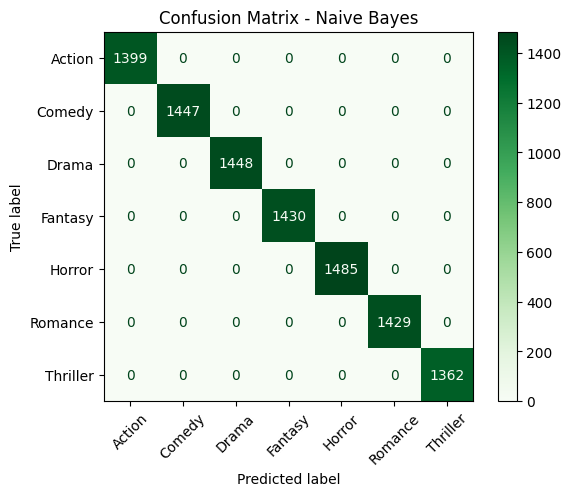

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_nb, y_pred_nb)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nb.classes_)
disp.plot(cmap=plt.cm.Greens, xticks_rotation=45)
plt.title("Confusion Matrix - Naive Bayes")
plt.show()

Il modello sembra classificare perfettamente i generi dei film.

## Support Vector Machine

Un **Support Vector Machine** è un algoritmo di apprendimento supervisionato utilizzato per la classificazione, il cui obiettivo principale è quello di trovare un iperpiano che separa i dati in classi distinte con il margine più ampio possibile di distanza tra i punti di altre classi. Se i dati non sono separabili linearmente, le **SVM** utilizzano i **kernel**, che trasformano i dati in modo da renderne possibile la separazione.  

In questo modello si useranno le variabili utilizzate per il Decision Tree e si applicheranno diversi kernel per testare l'accuratezza del modello. Verranno prese in considerazione solo le prime 1000 righe del dataset.  
Inizialmente si processano i dati in modo da trasformare le variabili categoriali in variabili numeriche con **LabelEncoder()**; successivamente si standardizzano i dati con **StandardScaler**, si riduce la dimensionalità dei dati con l'**Analisi in Componenti Principali** e si visualizza il grafico della distribuzione dei punti.

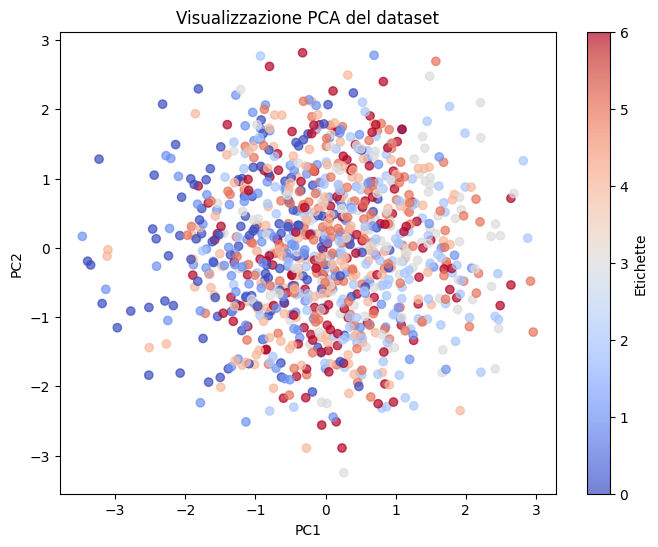

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv('/content/movie_genre_classification_final.csv', nrows=1000)
x_svm=data.drop(['Duration', 'Rating', 'Votes', 'Language', 'Budget_USD', 'BoxOffice_USD', 'Genre', 'Num_Awards'], axis=1)
y_svm=data['Genre']

y_enc= LabelEncoder().fit_transform(y_svm)
for col in x_svm.select_dtypes(include='object').columns:
    le = LabelEncoder()
    x_svm [col] = le.fit_transform(x_svm[col])

scaler = StandardScaler()
x_svm_scaled = scaler.fit_transform(x_svm)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_red = pca.fit_transform(x_svm_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_red[:, 0], X_red[:, 1], c=y_enc, cmap=plt.cm.coolwarm, alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Visualizzazione PCA del dataset")
plt.colorbar(label="Etichette")
plt.show()

Dal grafico si vede come i punti siano molto mescolati, quindi i diversi generi di film condividono delle caratteristiche e questo rende difficile distinguerli.  
Si valutano successivamente le performance sull'accuratezza di diversi kernel per addestrare il modello. Le funzioni **cross_val_score** e **SVC** servono rispettivamente ad eseguire una validazione incrociata e come classificatore del Support Vector Machine.

In [21]:
from sklearn.model_selection import cross_val_score
from sklearn.svm import SVC
import numpy as np

kernels = ["linear", "rbf", "poly", "sigmoid"]
scores = {}

for kernel in kernels:
    model = SVC(kernel=kernel)
    score = cross_val_score(model, x_svm_scaled, y_enc, cv=5, scoring="accuracy")
    scores[kernel] = score
    print(f"Kernel: {kernel}\tAccuracy media: {np.mean(score):.4f} ± {np.std(score):.4f}")

Kernel: linear	Accuracy media: 1.0000 ± 0.0000
Kernel: rbf	Accuracy media: 0.8970 ± 0.0144
Kernel: poly	Accuracy media: 0.6250 ± 0.0390
Kernel: sigmoid	Accuracy media: 0.9680 ± 0.0117


Da questa analisi sembra che il kernel **lineare**, **sigmoide** e **Radial Basis Function** siano quelli che lavorano meglio su questo dataset. Di seguito, creamo un grafico a barre per rappresentare i livelli di accuratezza raggiunti per ogni kernel.

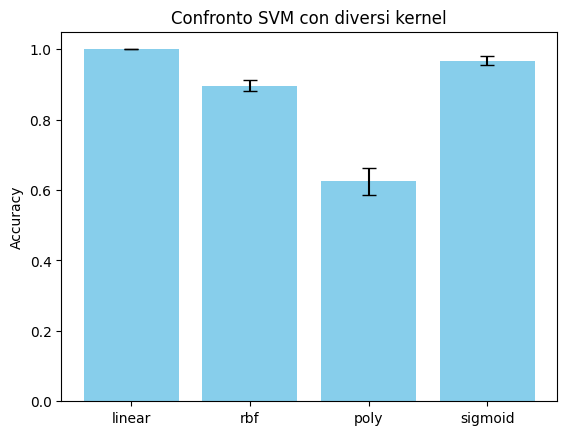

In [22]:
import matplotlib.pyplot as plt

means = [np.mean(scores[k]) for k in kernels]
errors = [np.std(scores[k]) for k in kernels]

plt.bar(kernels, means, yerr=errors, color="skyblue", capsize=5)
plt.ylabel("Accuracy")
plt.title("Confronto SVM con diversi kernel")
plt.show()

Il kernel lineare viene utilizzato per dati che sono già separabili nello spazio originale. Prima di proseguire con l'addestramento del modello secondo il kernel lineare, effettuiamo un'**ottimizzazione iperparametrica** per individuare l'iperparametro C più adatto per il modello sulla base dei dati. La funzione **GridSearchCV** esplora una griglia di valori iperparametrici per valutarne l'accuratezza.

In [23]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(SVC(kernel='linear'), param_grid, cv=5, scoring='accuracy')
grid.fit(x_svm_scaled, y_enc)

print("Miglior valore di C:", grid.best_params_['C'])
print("Accuracy media:", grid.best_score_)

Miglior valore di C: 0.1
Accuracy media: 1.0


Il miglior valore dell'iperparametro sembra essere **C=0.1**, con un'accuratezza massima. Di seguito, si visualizza il grafico con le variazione dell'accuratezza al variare di C.

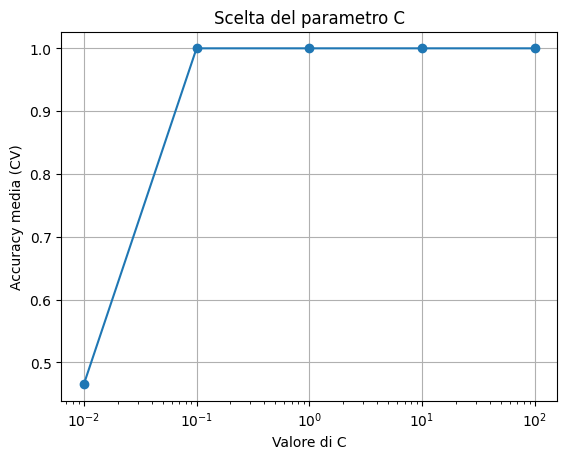

In [24]:
import matplotlib.pyplot as plt

results = grid.cv_results_
plt.plot(param_grid['C'], results['mean_test_score'], marker='o')
plt.xscale('log')
plt.xlabel("Valore di C")
plt.ylabel("Accuracy media (CV)")
plt.title("Scelta del parametro C")
plt.grid(True)
plt.show()

Si nota come all'aumentare di C dopo il valore 0.1 non si hanno variazioni dell'accuratezza, che raggiunge il valore massimo a 0.1 e rimane stabile.  
Addestriamo allora il modello secondo un kernel lineare e con l'iperparametro C trovato. Il modulo **DecisionBoundaryDisplay** è utile a mostrare il confine decisionale del classificatore.

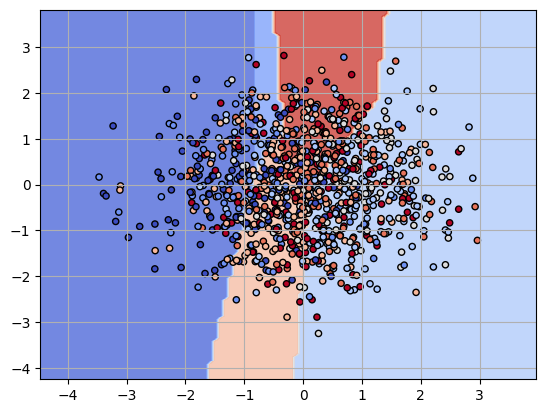

In [25]:
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

C = 0.1
model = SVC(kernel="linear", C=C)
model.fit(X_red, y_enc)

titles = "SVC with linear kernel",

fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X_red,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
    )
X0, X1 = (X_red[:, 0], X_red[:, 1])
ax.scatter(X0, X1, c=y_enc, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
plt.grid()

Dal grafico si nota come alcuni punti siano vicino al confine o nella regione sbagliata; questi potrebbero essere dati incerti o mal classificati.  
Dividiamo ora il dataset in un set di training e in un set di test, addestriamo il modello su questi e creiamo una Matrice di Confusione per valutare le prestazioni del modello sulle predizioni.

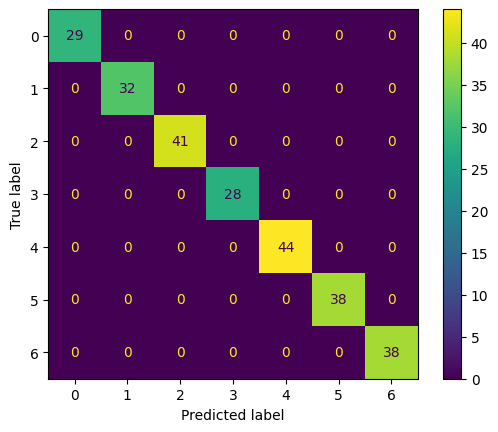

In [26]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(x_svm_scaled, y_enc, random_state=0)

classifier = svm.SVC(kernel="linear", C=0.1).fit(X_train_svm, y_train_svm)

predictions = classifier.predict(X_test_svm)
cm = confusion_matrix(y_test_svm, predictions, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classifier.classes_)
disp.plot()
plt.show()

Il modello sembra aver predetto perfettamente i dati di test, nonostante i confini decisionali non fossero chiari.  

Si procede applicando un altro kernel al modello. Si utilizza nuovamente **GridSearchCV** per cercare gli iperparametri C e **gamma** del kernel **sigmoide**. Questo kernel si ispira alle funzioni di attivazione delle reti neurali ed è utile quando si hanno classi non separabili linearmente.

In [27]:
param_grid = {
    'gamma': ['scale', 0.01, 0.1, 1],
    'coef0': [-1, 0, 1, 10],
    'C': [0.1, 1, 10]
}
grid = GridSearchCV(SVC(kernel='sigmoid'), param_grid, cv=5, scoring='accuracy')
grid.fit(x_svm_scaled, y_enc)

print("Migliori parametri:", grid.best_params_)
print("Accuracy media:", grid.best_score_)

Migliori parametri: {'C': 10, 'coef0': 0, 'gamma': 0.01}
Accuracy media: 1.0


Di seguito si crea una **heatmap** per visualizzare il variare dell'accuratezza al variare degli iperparametri C e gamma.

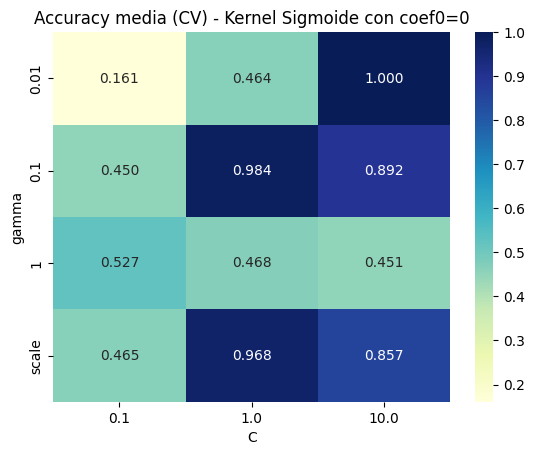

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

subset = results[results['param_coef0'] == 0]

pivot = subset.pivot(index='param_gamma', columns='param_C', values='mean_test_score')

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Accuracy media (CV) - Kernel Sigmoide con coef0=0")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

Diversi valori forniscono livelli di accuratezza ottimi. Di seguito si considereranno gli iperparametri **C=1.0** e **gamma=0.1**.  
Addestriamo allora il modello secondo un kernel sigmoide e con gli iperparametri trovati, rappresentando nuovamente il confine decisionale del modello.

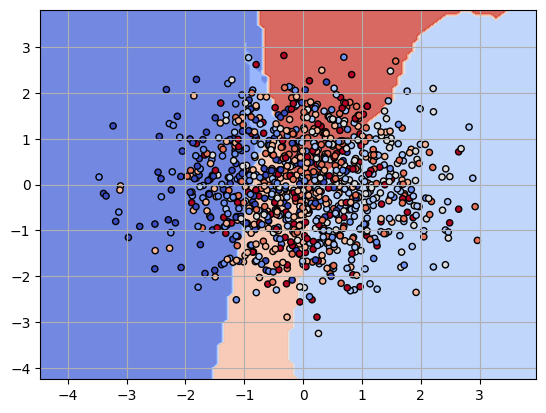

In [29]:
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

C = 1.0
model = SVC(kernel="sigmoid", gamma=0.1, C=C)
model.fit(X_red, y_enc)

titles = "SVC with sigmoid kernel",

fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X_red,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
    )
X0, X1 = (X_red[:, 0], X_red[:, 1])
ax.scatter(X0, X1, c=y_enc, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
plt.grid()

Il grafico, quindi i confini decisionali, sono simili a quelli ottenuti con un kernel lineare. Molti punti, ancora una volta, risultano essere rappresentati nella regione sbagliata, quindi sono mal classificati o incerti.  
Creiamo di seguito una Matrice di Confusione per testare la performance del modello sulle predizioni.

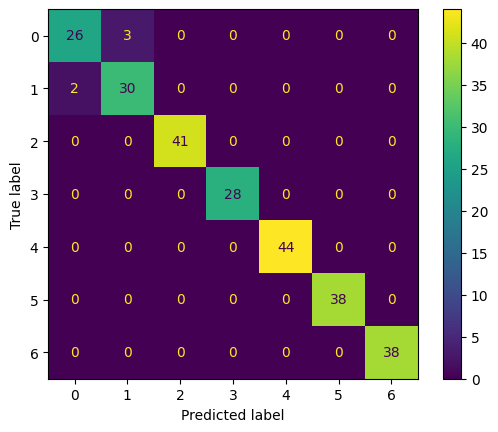

In [30]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(x_svm_scaled, y_enc, random_state=0)

classifier = svm.SVC(kernel="sigmoid",gamma=0.1, C=C).fit(X_train_svm, y_train_svm)

predictions = classifier.predict(X_test_svm)
cm = confusion_matrix(y_test_svm, predictions, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classifier.classes_)
disp.plot()
plt.show()

Il modello sembra predire abbastanza bene il genere dei film.  

Applichiamo, infine, il terzo kernel che è sembrato avere buoni livelli di accuratezza dalla validazione incrociata, il kernel **Radial Basis Function**. Anche questo kernel è usato per problemi non lineari ed ha l'obiettivo di mappare i dati in uno spazio infinito dove la separazione lineare diventa possibile.  
Utilizziamo nuovamente GridSearchCV per trovare il miglior valore degli iperparametri C e gamma.

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': [0.001, 0.01, 0.1, 1, 10]
}

grid = GridSearchCV(SVC(kernel='rbf'), param_grid, cv=5, scoring='accuracy')
grid.fit(x_svm_scaled, y_enc)

print("Migliori parametri:", grid.best_params_)
print("Accuracy media:", grid.best_score_)

Migliori parametri: {'C': 10, 'gamma': 0.01}
Accuracy media: 1.0


Di seguito si crea una **heatmap** per visualizzare il variare dell'accuratezza al variare degli iperparametri C e gamma.

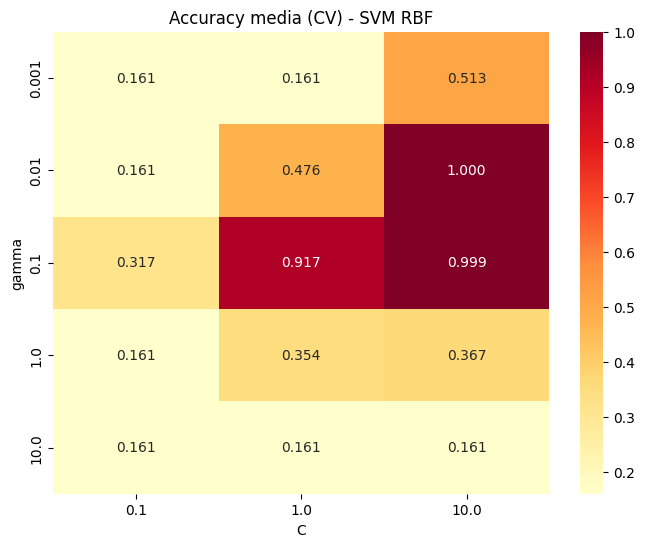

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot(index='param_gamma', columns='param_C', values='mean_test_score')

plt.figure(figsize=(8, 6))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd")
plt.title("Accuracy media (CV) - SVM RBF")
plt.xlabel("C")
plt.ylabel("gamma")
plt.show()

Anche in questo caso, diversi valori degli iperparametri sembrano dare un'ottima accuratezza. Di seguito verranno utilizzati per addestrare il modello i valori **C=1.0** e **gamma=0.1**. Si rappresenta ancora una volta il confine decisionale.

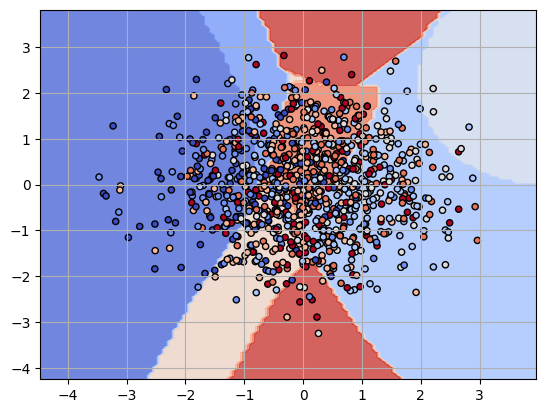

In [33]:
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

C = 1.0
model = SVC(kernel="rbf", gamma=0.1, C=C)
model.fit(X_red, y_enc)

titles = "SVC with sigmoid kernel",

fig, ax = plt.subplots()
disp = DecisionBoundaryDisplay.from_estimator(
        model,
        X_red,
        response_method="predict",
        cmap=plt.cm.coolwarm,
        alpha=0.8,
        ax=ax,
    )
X0, X1 = (X_red[:, 0], X_red[:, 1])
ax.scatter(X0, X1, c=y_enc, cmap=plt.cm.coolwarm, s=20, edgecolors="k")
plt.grid()

I confini decisionali del modello variano rispetto a quelli dei modelli precedenti, tuttavia i punti rimangono ancora sovrapposti e mal classificati.
Creiamo di seguito una Matrice di Confusione per testare la perfomance del modello sulle predizioni dei dati.

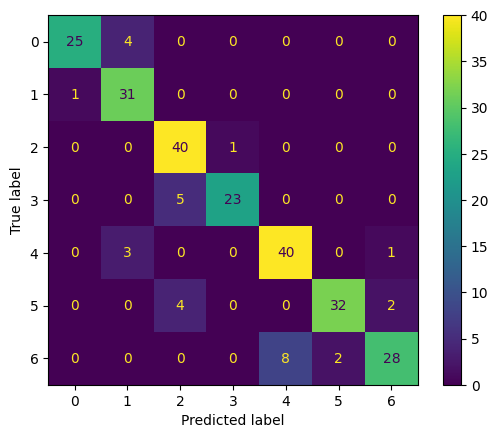

In [34]:
import matplotlib.pyplot as plt
from sklearn import datasets, svm
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split

X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(x_svm_scaled, y_enc, random_state=0)

classifier = svm.SVC(kernel="rbf",gamma=0.1, C=C).fit(X_train_svm, y_train_svm)

predictions = classifier.predict(X_test_svm)
cm = confusion_matrix(y_test_svm, predictions, labels=classifier.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=classifier.classes_)
disp.plot()
plt.show()

Il modello sembra predire molto bene i dati.

## K-means Clustering

Il modello K-means è un algoritmo di **clustering non supervisionato** utilizzato per suddividere un insieme di dati in gruppi distinti sulla base delle somiglianze tra i dati. Questa analisi è utile per individuare se i generi dei film si dividono spontaneamente sulla base delle loro variabili.  
In particolare, nel seguente modello verranno utilizzate tutte le variabili numeriche del dataset, ovvero **Duration**, **Rating**, **Votes**, **Budget_USD**, **BoxOffice_USD**, **Num_Awards** e **Critic_Reviews**. Queste variabili potrebbero evidenziare che magari film dello stesso genere hanno caratteristiche simili che potrebbero essere considerate allora proprie della tipologia di film, come ad esempio la durata o il budget di produzione. Per l'analisi verranno prese in considerazione solo le prime mille righe per semplificare i processi e per visualizzare meglio i dati.  

Inizialmente, si importa nuovamente il dataset, eliminando le colonne che non verranno prese in considerazione nell'analisi.  
Successivamente, con **StandardScaler()**, si normalizzano i dati del dataset, in modo che facciano riferimento ad una scala comune. In seguito, si riduce la dimensionalità attraverso l'Analisi in Componenti Principali, per eliminare dati rindondanti e ridurre il rumore.  
Infine, si visualizza il grafico in cui sono rappresentati i dati standardizzati e ridotti dalla PCA.

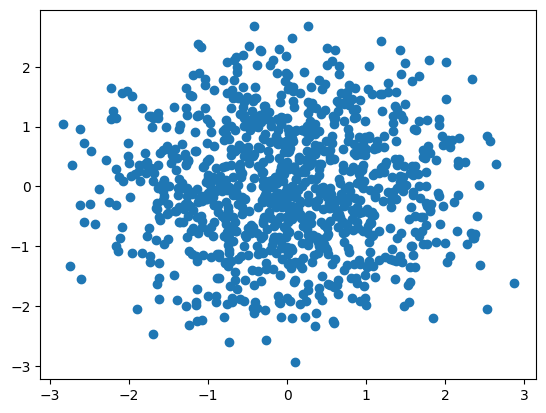

In [35]:
from sklearn import cluster
import pandas as pd

data_K=pd.read_csv('/content/movie_genre_classification_final.csv', nrows=1000)
genre_labels = data_K['Genre']
data = data_K.drop(['Year','Title', 'Director', 'Description', 'Language', 'Country', 'Genre', 'Production_Company', 'Content_Rating', 'Lead_Actor'],axis=1)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaleddf = scaler.fit_transform(data)

from sklearn.decomposition import PCA

df_pca = PCA(n_components=2).fit_transform(scaleddf)
plt.scatter(df_pca[:,0], df_pca[:,1],alpha=1)
plt.show()

Dopo aver concluso la preparazione dei dati, si procede con il **Metodo del Gomito** per valutare il numero di cluster ottimale da utilizzare nell'analisi. Per ogni cluster si memorizzano i valori del **Sum of Squared Errors**, ovvero la somma delle distanze quadratiche tra ciscun punto e il centro del proprio cluster.  
In seguito, si crea e visualizza il grafico con il numero di cluster sull'asse X e l'SSE sull'asse Y. Il numero ottimale di cluster è dato dal punto in cui il decremento dell'SSE rallenta.

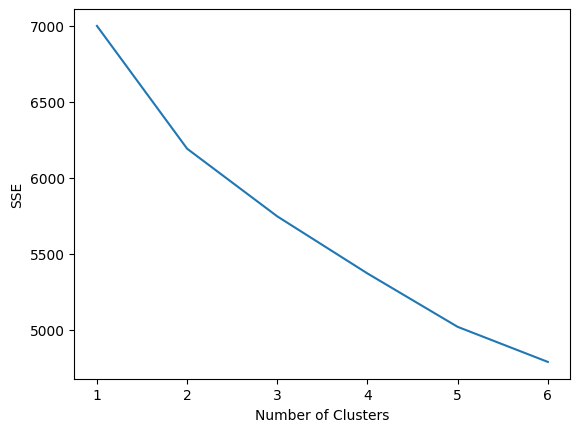

In [36]:
import matplotlib.pyplot as plt

numClusters = [1,2,3,4,5,6]
SSE = []
for k in numClusters:
    k_means = cluster.KMeans(n_clusters=k)
    k_means.fit(scaleddf)
    SSE.append(k_means.inertia_)

plt.plot(numClusters, SSE)
plt.xlabel('Number of Clusters')
plt.ylabel('SSE')
plt.show()

Secondo il grafico, il numero ottimale di cluster da prendere in considerazione è tra 3 e 4.  
Considerando quattro cluster, di seguito si procede con la definizione dei cluster attraverso il modulo **Kmeans** di **scikit-learn** sui dati normalizzati. Successivamente, si visualizza il grafico in cui sono evidenziati con colori dofferenti i diversi cluster.

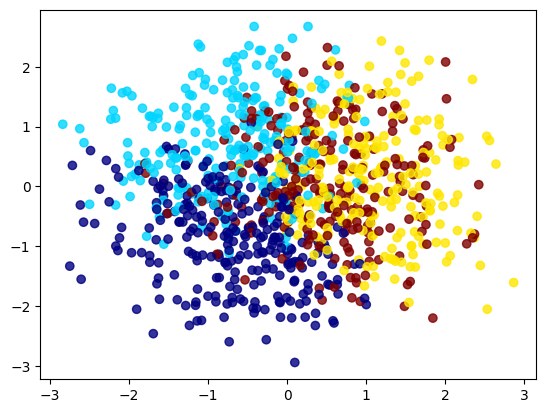

In [37]:
from sklearn.cluster import KMeans
clf = KMeans(n_clusters = 4)
clf.fit(scaleddf)
labels = clf.labels_

import matplotlib.pyplot as plt
plt.scatter(df_pca[:,0], df_pca[:,1], alpha=0.8, c=labels, cmap='jet')
plt.show()

Il grafico mostra che i cluster possono essere definiti, ma non sono ben distinti tra loro.  
Si calcola e si visualizza a schermo il valore dell'SSE.

In [39]:
print('SSE of data\'s cluster result  =' , clf.inertia_)

SSE of data's cluster result  = 5348.4974103213


IL **Sum of Squared Errors** corrisponde a 5348,4974; questo potrebbe indicare che i dati sono poco separabili o il modello non è in grado di distinguere efficacemente i gruppi.  
Si analizza di seguito il **Silhouette Score**, ovvero una metrica che misura quanto bene un punto è assegnato al proprio cluster rispetto agli altri cluster.

In [40]:
from sklearn.metrics import silhouette_score

print('Silhouette score of data\'s cluster result =',silhouette_score(scaleddf,clf.labels_))

Silhouette score of data's cluster result = 0.09984912184116396


Il valore del Silhouette score è di 0,09984; questo conferma che ci sono delle sovrapposizione o della confusione tra i cluster, oppure che il modello non sta riflettendo la struttura dei dati.  
In seguito, calcoliamo la **Matrice di Similarità**, utile a valutare la coerenza interna dei gruppi. Si utilizza la **distanza del coseno**.

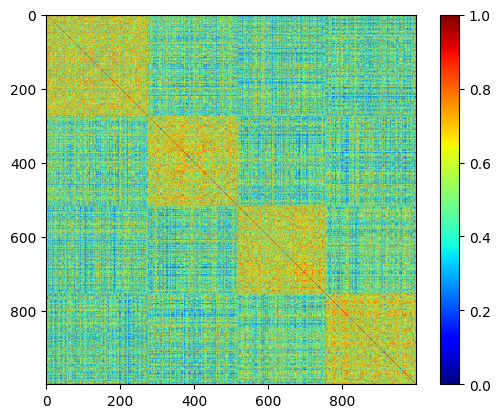

In [41]:
import numpy as np
from sklearn.metrics import pairwise_distances

indes_of_labels = np.argsort(clf.labels_)

pairwisedist = pairwise_distances(scaleddf, metric ='cosine')
sorted_pairwisedist = pairwisedist[indes_of_labels][:,indes_of_labels]
labels_rand = clf.labels_[indes_of_labels]

sorted_pairwisedist = sorted_pairwisedist / np.max(sorted_pairwisedist)
sorted_similarity = 1- sorted_pairwisedist / np.max(sorted_pairwisedist)

import matplotlib.pyplot as plt
plt.imshow(sorted_similarity,cmap ='jet')
plt.colorbar()
plt.show()

Il grafico della Matrice delle Distanze ottenuto fa pensare che esistano dei cluster coerenti internamente e distinti da altri cluster. Potrebbe quindi esistere una struttura tra i dati anche se il Silhouette Score risulta basso.  
Si calcola e si visualizza allora la **Matrice delle Distanze**, che mostra quanto sono diversi tra loro i punti del dataset.

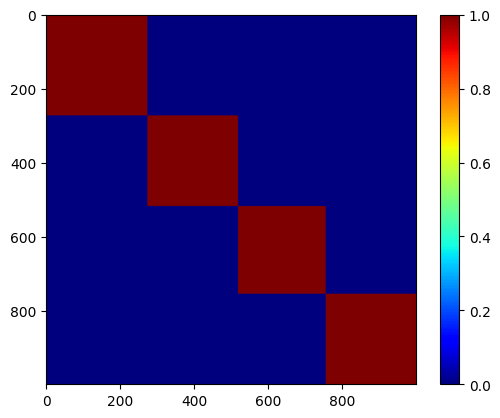

In [42]:
incidence_matrix_random = np.zeros_like(sorted_similarity)
for i in range(len(labels_rand)):
    for j in range(len(labels_rand)):
        incidence_matrix_random[i,j] = int(labels_rand[i] == labels_rand[j])

plt.imshow(incidence_matrix_random,cmap ='jet')
plt.colorbar()
plt.show()

La Matrice delle Distanze conferma la coerenza all'interno dei quattro cluster e conferma che questi si differenziano dal resto dei punti nel dataset.  
Si valuta allora la correlazione tra le due Matrici.

In [43]:
corr_org = np.corrcoef(sorted_pairwisedist.flatten(), incidence_matrix_random.flatten())

corr_org[0][1]

np.float64(-0.3689712362610698)

Una correlazione di -0,37 afferma che le due matrici sono moderatamente correlate, quindi i dati potrebbero avere una struttura più complessa o non lineare che non viene calcolata; comunque si identificano dei cluster poiché la correlazione negativa indica che all'aumentare della similarità dei punti, quindi all'identificazione di un cluster, si riduce la distanza tra questi, quindi si separano più o meno nettamente i cluster dal resto dei dati.  
Altre analisi, con modelli diversi, potrebbero fornire risultati migliori.

## Conclusioni

In conclusione, i dati presenti nel dataset di riferimento non possono essere divisi o classificati perfettamente. Ciononostante, i modelli supervisionati (Multinominal Naive Bayes e Support Vector Machine) sembrano aver ottenuto ottime performance nel classificare il genere dei film. In particolare, sembra che i modelli testuali (Multinominal Naive Bayes) siano molto potenti nel predire il genere, suggerendo che i dati di testo sono molto informativi in questo dataset.  
Il dataset non sembra adatto all'analisi dei cluster. Si evidenzia una struttura latente dei film, ma non si riesce a trovare delle classi chiare con cui raggrupparli.  
L'analisi può essere estesa e migliorata attraverso l'applicazione di modelli di classificatori più avanzati, attraverso l'uso delle reti neurali, attraverso l'utilizzo di dati reali o integrando nuove variabili che potrebbero essere più rilevanti per l'individuazione del genere.